In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [10]:
from datasets import load_dataset

dataset = load_dataset(
    "kevincluo/structure_wildfire_damage_classification",
    streaming=True
)

train_data = dataset["train"]

In [13]:
images = []
labels = []

for sample in dataset["train"]:
    img = sample["image"]
    img = img.resize((224,224))
    img = np.array(img)

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    if img.shape[-1] == 4:
        img = img[:,:,:3]

    images.append(img)
    labels.append(sample["label"])

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print(X.shape, y.shape)

(18714, 224, 224, 3) (18714,)


In [14]:
X = X / 255.0

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [18]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [19]:
cnn_model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),
    
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(
        6,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

c:\Users\SHARIQ ALI\OneDrive\Desktop\Wildfire-Damage-Classification\wildfire-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(13099, 224, 224, 3) (2807, 224, 224, 3) (2808, 224, 224, 3)


In [22]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)
y_test_cat = to_categorical(y_test)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\SHARIQ ALI\OneDrive\Desktop\Wildfire-Damage-Classification\wildfire-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # CHANGE THIS
    metrics=['accuracy']
)

In [27]:
y_train_cat
y_val_cat

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.]], shape=(2807, 6))

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
images = []
labels = []

for i, sample in enumerate(dataset["train"]):
    
    if i >= 5000:   # limit dataset to avoid crash
        break

    img = sample["image"]
    img = img.resize((224,224))
    img = np.array(img)

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    if img.shape[-1] == 4:
        img = img[:,:,:3]

    images.append(img)
    labels.append(sample["label"])

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/kevincluo/structure_wildfire_damage_classification/resolve/fdd875691f8111ba22dc08193403235537b1bb28/data/train-00000-of-00009-c8a5637a3d1a80e9.parquet
Retrying in 1s [Retry 1/5].


In [31]:
X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)

In [32]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16   # IMPORTANT: reduce batch size
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 1236s 1s/step - accuracy: 0.7830 - loss: 0.6756 - val_accuracy: 0.8443 - val_loss: 0.5241
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 753s 916ms/step - accuracy: 0.8454 - loss: 0.5134 - val_accuracy: 0.8450 - val_loss: 0.5256
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 697s 851ms/step - accuracy: 0.8651 - loss: 0.4519 - val_accuracy: 0.8728 - val_loss: 0.4672
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 281s 343ms/step - accuracy: 0.8784 - loss: 0.3888 - val_accuracy: 0.8821 - val_loss: 0.4397
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 283s 346ms/step - accuracy: 0.8910 - loss: 0.3420 - val_accuracy: 0.8732 - val_loss: 0.4798
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 280s 342ms/step - accuracy: 0.9101 - loss: 0.2697 - val_accuracy: 0.8717 - val_loss: 0.5082
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 281s 343ms/step - accuracy: 0.9273 - loss: 0.2109 - val_accuracy: 0.8796 - val_loss: 0.5168
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 275s 335ms/step - accuracy: 0.9447 - l

In [4]:
import matplotlib.pyplot as plt

In [8]:
print("history" in globals())

False


In [10]:
print("dataset exists:", "dataset" in globals())

dataset exists: False


In [11]:
print("X_train exists:", "X_train" in globals())
print("X_val exists:", "X_val" in globals())

X_train exists: False
X_val exists: False


In [12]:
print("model exists:", "model" in globals())

model exists: False


In [13]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("model:", "model" in globals())
print("history:", "history" in globals())

dataset: False
X: False
X_train: False
X_val: False
model: False
history: False


In [17]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("y:", "y" in globals())

dataset: False
X: False
y: False


In [ ]:
print("X:", "X" in globals())
print("y:", "y" in globals())

In [21]:
print("dataset:", "dataset" in globals())
print("X:", "X" in globals())
print("y:", "y" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("model:", "model" in globals())
print("cnn_history:", "cnn_history" in globals())
print("history:", "history" in globals())

dataset: False
X: False
y: False
X_train: False
X_val: False
model: False
cnn_history: False
history: False


In [42]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [44]:
!pip install tensorflow

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

In [46]:
print(tf.__version__)

2.21.0


In [48]:
%whos

Variable                Type        Data/Info
---------------------------------------------
class_names             list        n=6
classification_report   function    <function classification_<...>rt at 0x0000021B6FA431A0>
confusion_matrix        function    <function confusion_matrix at 0x0000021B6FA41E40>
np                      module      <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
plt                     module      <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns                     module      <module 'seaborn' from 'c<...>s\\seaborn\\__init__.py'>
tf                      module      <module 'tensorflow' from<...>tensorflow\\__init__.py'>
train_test_split        function    <function train_test_split at 0x0000021B6FAD27A0>


In [49]:
import numpy as np
import tensorflow as tf
from datasets import load_dataset

c:\Users\SHARIQ ALI\OneDrive\Desktop\Wildfire-Damage-Classification\wildfire-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
!pip install huggingface_hub

In [54]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="kevincluo/structure_wildfire_damage_classification",
    repo_type="dataset"
)

print(dataset_path)

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]c:\Users\SHARIQ ALI\OneDrive\Desktop\Wildfire-Damage-Classification\wildfire-env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-developmen

C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28


In [55]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(files[:5])
    print("-"*50)

C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28
['.gitattributes', 'README.md']
--------------------------------------------------
C:\Users\SHARIQ ALI\.cache\huggingface\hub\datasets--kevincluo--structure_wildfire_damage_classification\snapshots\fdd875691f8111ba22dc08193403235537b1bb28\data
['train-00000-of-00009-c8a5637a3d1a80e9.parquet', 'train-00001-of-00009-92d3029f18f7fed9.parquet', 'train-00002-of-00009-4c1dcecc6d84bf3c.parquet', 'train-00003-of-00009-ed945d9945c16977.parquet', 'train-00004-of-00009-79f29caa7513e947.parquet']
--------------------------------------------------


In [56]:
import pandas as pd
import os

parquet_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".parquet"):
            parquet_files.append(os.path.join(root, file))

print("Number of parquet files:", len(parquet_files))
print(parquet_files[:3])

Number of parquet files: 9
['C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00000-of-00009-c8a5637a3d1a80e9.parquet', 'C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00001-of-00009-92d3029f18f7fed9.parquet', 'C:\\Users\\SHARIQ ALI\\.cache\\huggingface\\hub\\datasets--kevincluo--structure_wildfire_damage_classification\\snapshots\\fdd875691f8111ba22dc08193403235537b1bb28\\data\\train-00002-of-00009-4c1dcecc6d84bf3c.parquet']


In [57]:
df = pd.read_parquet(parquet_files[0])

print(df.head())
print(df.columns)
print(df.shape)

                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
Index(['image', 'label'], dtype='str')
(2080, 2)


In [58]:
print(df.columns)

Index(['image', 'label'], dtype='str')


In [59]:
df.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [60]:
import pandas as pd
import os

all_dfs = []

for parquet_file in parquet_files:
    temp_df = pd.read_parquet(parquet_file)
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print(df.shape)
df.head()

(18714, 2)


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [61]:
print(df["label"].value_counts())

label
1    9385
5    7654
0    1234
4     293
3     124
2      24
Name: count, dtype: int64


In [62]:
from PIL import Image
from io import BytesIO
import numpy as np

IMG_SIZE = (224, 224)

def process_image(image_dict):
    image_bytes = image_dict["bytes"]

    img = Image.open(BytesIO(image_bytes))
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)

    return np.array(img) / 255.0

In [66]:
print(df.shape)

(18714, 2)


In [68]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

13099
2807
2808


In [70]:
import tensorflow as tf
from PIL import Image
from io import BytesIO
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32(X_train.shape)
print(y_train.shape)
print(num_classes)

<>:7: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:7: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
C:\Users\SHARIQ ALI\AppData\Local\Temp\ipykernel_34000\859558535.py:7: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  BATCH_SIZE = 32(X_train.shape)


NameError: name 'X_train' is not defined

In [71]:
def preprocess_record(image_dict, label):
    image_bytes = image_dict["bytes"]

    img = Image.open(BytesIO(image_bytes))
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)

    img = np.array(img, dtype=np.float32) / 255.0

    return img, label

In [72]:
def dataframe_generator(dataframe):
    for _, row in dataframe.iterrows():
        yield preprocess_record(
            row["image"],
            row["label"]
        )

In [73]:
num_classes = df["label"].nunique()

print(num_classes)

6


In [74]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(train_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(val_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

test_dataset = tf.data.Dataset.from_generator(
    lambda: dataframe_generator(test_df),
    output_signature=(
        tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

In [75]:
def encode_label(image, label):
    return image, tf.one_hot(label, depth=num_classes)

In [76]:
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [77]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [78]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [80]:
cnn_model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

c:\Users\SHARIQ ALI\OneDrive\Desktop\Wildfire-Damage-Classification\wildfire-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
print("num_classes =", num_classes)

num_classes = 6


In [88]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print(labels[0])

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
tf.Tensor(1, shape=(), dtype=int64)


In [91]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
print(df["label"].unique())
print(sorted(df["label"].unique()))

[0 1 2 3 4 5]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [97]:
Dense(num_classes, activation='softmax')

NameError: name 'Dense' is not defined

In [98]:
for images, labels in train_dataset.take(1):
    print(labels.shape)

(32,)


In [101]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:
print(sorted(df["label"].unique()))
print("num_classes =", num_classes)

for images, labels in train_dataset.take(1):
    print("labels shape =", labels.shape)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
num_classes = 6
labels shape = (32,)


In [105]:
import os

os.makedirs("../models", exist_ok=True)

cnn_model.save("../models/cnn_model.keras")

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=train_labels)
plt.title("Class Distribution in Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

NameError: name 'train_labels' is not defined

<Figure size 800x500 with 0 Axes>

In [109]:
import random

plt.figure(figsize=(10,10))

for i in range(9):
    idx = random.randint(0, len(train_images)-1)
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[idx])
    plt.title(f"Label: {train_labels[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'train_images' is not defined

<Figure size 1000x1000 with 0 Axes>

In [110]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [111]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [112]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NameError: name 'model' is not defined

In [113]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom CNN", "EfficientNetB0"],
    "Accuracy": [cnn_acc, tl_acc],
    "Loss": [cnn_loss, tl_loss]
})

results

NameError: name 'cnn_acc' is not defined

In [114]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_val, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report

NameError: name 'y_val' is not defined

In [115]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_df = pd.DataFrame({
    "Class": list(set(train_labels)),
    "Accuracy": class_accuracy
})

class_df

NameError: name 'cm' is not defined

In [116]:
import matplotlib.pyplot as plt
from collections import Counter

labels = dataset["train"]["label"]
counts = Counter(labels)

plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

NameError: name 'dataset' is not defined

In [119]:
import matplotlib.pyplot as plt

labels = dataset["train"]["label"]
counts = Counter(labels)

plt.pie(counts.values(), labels=counts.keys(), autopct="%1.1f%%")
plt.title("Damage Severity Distribution")
plt.show()

NameError: name 'dataset' is not defined

NameError: name 'dataset' is not defined

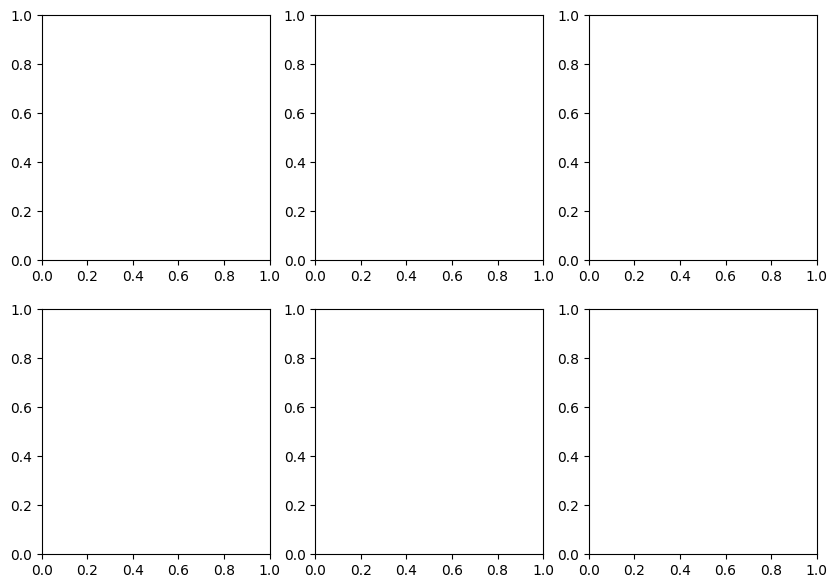

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i, ax in enumerate(axes.flat):
    img = dataset["train"][i]["image"]
    label = dataset["train"][i]["label"]
    ax.imshow(img)
    ax.set_title(f"Class: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()